add prompt variants to concept bank

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(r"C:\Users\Vivian\Documents\CONCH")
sys.path.insert(0, str(PROJECT_ROOT))

from conch.open_clip_custom import create_model_from_pretrained, tokenize, get_tokenizer
import torch
import os
from PIL import Image
from pathlib import Path

# show all jupyter output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

c:\Users\Vivian\anaconda3\envs\conch\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
model_cfg = 'conch_ViT-B-16'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# checkpoint_path = 'checkpoints/CONCH/pytorch_model.bin'
checkpoint_path = 'C:\\Users\\Vivian\\Documents\\CONCH\\checkpoints\\conch\\pytorch_model.bin' 
# checkpoint_path = r"C:\Users\Vivian\Documents\CONCH\_finetune_weights\fine_tuned_model2.pth" # testing with finetuned conch model
model, preprocess = create_model_from_pretrained(model_cfg, checkpoint_path, device=device)
_ = model.eval()

C:\Users\Vivian\Documents\CONCH\conch\open_clip_custom\factory.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map

In [3]:
# import torch
from transformers import AutoTokenizer
tokenizer = get_tokenizer()

creating concept bank in separate json and loading that instead

In [4]:
import json

with open(r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_map.json", "r", encoding="utf-8") as f:
    PROMPTS = json.load(f)

In [5]:
assert "templates" in PROMPTS
assert "classes" in PROMPTS
assert "concepts" in PROMPTS

In [ ]:
# create concept prior
import os
import glob
import argparse
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn.functional as F
from PIL import Image


# -------------------------
# NPY -> PIL
# -------------------------
def load_npy_as_pil(npy_path: str) -> Image.Image:
    arr = np.load(npy_path)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    return Image.fromarray(arr)


# -------------------------
# Text encoding (matches your working signature)
# -------------------------
def encode_text_prompts(prompts: List[str], tokenizer, model, device: str) -> np.ndarray:
    enc = tokenizer(prompts, padding=True, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.inference_mode():
        txt = model.encode_text(enc["input_ids"])
        txt = F.normalize(txt, dim=-1)
    return txt.detach().cpu().numpy()


# -------------------------
# Image encoding
# -------------------------
def encode_patch_embedding(npy_path: str, preprocess, model, device: str) -> np.ndarray:
    img = load_npy_as_pil(npy_path)
    x = preprocess(img).unsqueeze(0).to(device)
    with torch.inference_mode():
        e = model.encode_image(x)
        e = F.normalize(e, dim=-1)
    return e.detach().cpu().numpy()[0]


# -------------------------
# Prompt-bank builders
# -------------------------
def build_flat_class_prompts(P: dict) -> Tuple[List[str], np.ndarray, List[str]]:
    """
    templates × class synonyms -> flat prompts + class index map
    """
    templates = P["templates"]
    classes = P["classes"]
    class_names = list(classes.keys())  # ["FA","PT","NORMAL"] in your dict

    flat_prompts: List[str] = []
    flat_class_map: List[int] = []

    for ci, cls in enumerate(class_names):
        for syn in classes[cls]:
            for t in templates:
                flat_prompts.append(t.format(syn))
                flat_class_map.append(ci)

    return flat_prompts, np.array(flat_class_map, dtype=int), class_names


# def build_flat_concepts(P: dict) -> Tuple[List[str], List[str], Dict[str, List[int]]]:
#     """
#     Flatten all concept prompts; also return indices per concept group.
#     Dedupe while preserving order (important).
#     """
#     concept_list: List[str] = []
#     concept_group: List[str] = []
#     for grp, plist in P["concepts"].items():
#         for p in plist:
#             concept_list.append(p)
#             concept_group.append(grp)

#     # dedupe preserving order
#     seen = set()
#     out_list, out_group = [], []
#     for p, g in zip(concept_list, concept_group):
#         if p not in seen:
#             out_list.append(p)
#             out_group.append(g)
#             seen.add(p)

#     concept_list = out_list
#     concept_group = out_group

#     group_to_indices: Dict[str, List[int]] = {}
#     for i, g in enumerate(concept_group):
#         group_to_indices.setdefault(g, []).append(i)

#     return concept_list, concept_group, group_to_indices

# # NEW flat concept function
# def build_flat_concepts(P: dict):
#     """
#     Build one embedding per canonical concept by averaging embeddings
#     of its prompt variants later.

#     Returns:
#         concept_names: list[str]              # canonical concept names
#         concept_group: list[str]              # group per concept
#         concept_variants: list[list[str]]     # prompt variants per concept
#         group_to_indices: dict[str, list[int]]
#     """
#     concept_names = []
#     concept_group = []
#     concept_variants = []

#     for grp, concept_dict in P["concepts"].items():
#         for concept_name, variants in concept_dict.items():
#             concept_names.append(concept_name)
#             concept_group.append(grp)
#             concept_variants.append(variants)

#     group_to_indices = {}
#     for i, g in enumerate(concept_group):
#         group_to_indices.setdefault(g, []).append(i)

#     return concept_names, concept_group, concept_variants, group_to_indices

# return score for each concept variant
def build_flat_concepts(P: dict):
    concept_names = []
    concept_group = []
    concept_variants = []
    variant_rows = []

    for grp, concept_dict in P["concepts"].items():
        for concept_name, variants in concept_dict.items():
            concept_idx = len(concept_names)

            concept_names.append(concept_name)
            concept_group.append(grp)
            concept_variants.append(variants)

            for variant_idx, variant_text in enumerate(variants):
                variant_rows.append({
                    "concept_idx": concept_idx,
                    "concept_group": grp,
                    "concept_name": concept_name,
                    "variant_idx": variant_idx,
                    "variant_text": variant_text,
                })

    group_to_indices = {}
    for i, g in enumerate(concept_group):
        group_to_indices.setdefault(g, []).append(i)

    return concept_names, concept_group, concept_variants, group_to_indices, variant_rows

# NEW to average concept variants
# def encode_concept_bank(concept_variants, tokenizer, model, device: str) -> np.ndarray:
#     """
#     concept_variants: list of list of prompt strings
#     returns: (N_concepts, D)
#     """
#     concept_embs = []

#     for variants in concept_variants:
#         enc = tokenizer(variants, padding=True, return_tensors="pt")
#         enc = {k: v.to(device) for k, v in enc.items()}

#         with torch.inference_mode():
#             txt = model.encode_text(enc["input_ids"])
#             txt = F.normalize(txt, dim=-1)     # normalize each prompt embedding
#             txt = txt.mean(dim=0, keepdim=True) # average prompt variants
#             txt = F.normalize(txt, dim=-1)     # renormalize averaged concept embedding

#         concept_embs.append(txt.detach().cpu())

#     return torch.cat(concept_embs, dim=0).numpy()

# save variants separately and average later
def encode_concept_bank(concept_variants, tokenizer, model, device: str):
    """
    Returns:
        concept_embs_np: (N_concepts, D) averaged concept embeddings
        variant_embs_by_concept: list of np.ndarray, each (K_i, D)
    """
    concept_embs = []
    variant_embs_by_concept = []

    for variants in concept_variants:
        enc = tokenizer(variants, padding=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.inference_mode():
            txt = model.encode_text(enc["input_ids"])
            txt = F.normalize(txt, dim=-1)          # (K, D)

            variant_embs_by_concept.append(txt.detach().cpu().numpy())

            txt_mean = txt.mean(dim=0, keepdim=True)  # (1, D)
            txt_mean = F.normalize(txt_mean, dim=-1)
            concept_embs.append(txt_mean.detach().cpu())

    return torch.cat(concept_embs, dim=0).numpy(), variant_embs_by_concept

# -------------------------
# Patch scoring
# -------------------------
def softmax_np(x: np.ndarray) -> np.ndarray:
    x = x - np.max(x)
    e = np.exp(x)
    return e / (e.sum() + 1e-12)


def patch_class_probs(img_emb: np.ndarray, text_emb_class: np.ndarray, flat_class_map: np.ndarray, n_classes: int) -> np.ndarray:
    """
    For stability:
      sims -> softmax across ALL prompts -> average mass per class -> normalize
    """
    sims = img_emb @ text_emb_class.T  # (M,)
    p_prompt = softmax_np(sims)        # (M,)

    out = np.zeros(n_classes, dtype=float)
    for c in range(n_classes):
        out[c] = p_prompt[flat_class_map == c].mean()
    out = out / (out.sum() + 1e-12)
    return out  # (C,)


def patch_concept_sims(img_emb: np.ndarray, text_emb_concepts: np.ndarray) -> np.ndarray:
    """
    Raw cosine similarity per canonical concept
    """
    return img_emb @ text_emb_concepts.T  # (Nconcept,)

def load_slide_pt(pt_path: str):
    obj = torch.load(pt_path, map_location="cpu", weights_only=True)

    feats = obj["features"].float()
    coords = obj["coords"].int()

    feats = F.normalize(feats, dim=1)

    return feats.numpy(), coords.numpy()

# mass vis h5 feats---------------
# import h5py
# import torch
# import torch.nn.functional as F

# def load_slide_h5(h5_path: str):
#     import h5py
#     import torch
#     import torch.nn.functional as F

#     with h5py.File(h5_path, "r") as f:
#         # embeddings may be nested inside a group
#         if isinstance(f["embeddings"], h5py.Group):
#             inner_key = list(f["embeddings"].keys())[0]
#             feats = f["embeddings"][inner_key][:]
#         else:
#             feats = f["embeddings"][:]

#         coords = f["embed_loc"][:]

#     feats = torch.from_numpy(feats).float()
#     feats = F.normalize(feats, dim=1)

#     return feats.numpy(), coords.astype(int)
# --------------------------------

# -------------------------
# Slide scoring (aggregate patches)
# -------------------------
def classify_slide_pt(
    slide_id: str,
    pt_path: str,
    text_emb_class: np.ndarray,
    flat_class_map: np.ndarray,
    class_names: List[str],
    text_emb_concepts: np.ndarray,
    group_to_indices: Dict[str, List[int]],
    max_patches: Optional[int] = 800,
    topk_patches: Optional[int] = 200,
    select_mode: str = "conf",
    select_bucket: str = "PT_lean",
    seed: int = 0,
):
    E, coords = load_slide_pt(pt_path) # og

    # E, coords = load_slide_h5(pt_path) # h5 mass vis feats
    # print(E.shape)       # should be (N, 512)
    # print(coords.shape)  # should be (N, 2)

    N = E.shape[0]

    if max_patches is not None and N > max_patches:
        rng = np.random.default_rng(seed)
        idx_cap = rng.choice(N, size=max_patches, replace=False)
        E = E[idx_cap]
        coords = coords[idx_cap]

    # ---- vectorized scoring ----
    sims_class = E @ text_emb_class.T
    sims_class = sims_class - sims_class.max(axis=1, keepdims=True)
    p_prompt = np.exp(sims_class)
    p_prompt /= p_prompt.sum(axis=1, keepdims=True)

    n_classes = len(class_names)
    patch_probs = np.zeros((E.shape[0], n_classes))
    for c in range(n_classes):
        patch_probs[:, c] = p_prompt[:, flat_class_map == c].mean(axis=1)

    patch_probs /= patch_probs.sum(axis=1, keepdims=True)

    patch_conf = patch_probs.max(axis=1)

    patch_concept = E @ text_emb_concepts.T

    # selection
    if select_mode == "conf":
        select_score = patch_conf
    else:
        inds = group_to_indices[select_bucket]
        select_score = patch_concept[:, inds].mean(axis=1)

    if topk_patches is not None and topk_patches < E.shape[0]:
        idx = np.argsort(-select_score)[:topk_patches]
        patch_probs = patch_probs[idx]
        patch_concept = patch_concept[idx]
        coords = coords[idx]

    # slide_probs = patch_probs.mean(axis=0)
    # pred_idx = int(np.argmax(slide_probs))
    # pred_name = class_names[pred_idx]
    
    slide_probs = patch_probs.mean(axis=0)
    pred_idx = int(np.argmax(slide_probs))
    pred_name = class_names[pred_idx]
    margin = float(np.sort(slide_probs)[-1] - np.sort(slide_probs)[-2]) if len(slide_probs) >= 2 else np.nan


    mean_concept = patch_concept.mean(axis=0)
    # mean_concept = patch_concept.max(axis=0)

    topc_idx = np.argsort(-mean_concept)[:15]
    top_concepts = [(int(i), float(mean_concept[i])) for i in topc_idx]


    bucket_scores = {}
    for grp, inds in group_to_indices.items():
        bucket_scores[f"bucket_{grp}"] = float(np.mean(mean_concept[inds]))

    return {
    "slide_probs": slide_probs,
    "pred_name": pred_name,
    "margin": margin,
    "n_patches_scored": int(N),            # before cap/topk (or after cap; your choice)
    "n_patches_used": int(patch_probs.shape[0]),
    "bucket_scores": bucket_scores,
    "top_concepts": top_concepts,          # if you still want it
    "mean_concept": mean_concept,

    # NEW: patch-level outputs
    "patch_concept": patch_concept,   # (n_used, n_concepts)
    "patch_probs": patch_probs,       # (n_used, n_classes) optional
    "coords": coords,                 # (n_used, 2)
    "E_used": E,   # features after cap/topk
}


# -------------------------
# Dataset scanning
# -------------------------
def list_slide_dirs(mag_root: str):
    out = []
    pt_files = sorted(glob.glob(os.path.join(mag_root, "*.pt")))
    for p in pt_files:
        slide_id = os.path.splitext(os.path.basename(p))[0]
        out.append((slide_id, p))
    return out


# def infer_label_from_path(slide_dir: str) -> str:
#     # label string from parent folder name
#     return os.path.basename(os.path.dirname(slide_dir)).upper()

def infer_label_from_path(pt_path: str) -> str:
    slide_id = os.path.splitext(os.path.basename(pt_path))[0]
    return slide_id.split()[0].upper()  # assumes "FA 56B", "PT 12B"

import os, glob, re

def list_slide_pt_files(mag_root: str):
    # mag_root example: ...\40x\pt
    files = sorted(glob.glob(os.path.join(mag_root, "*.pt")))
    return [(os.path.splitext(os.path.basename(p))[0], p) for p in files]

def infer_label_from_slide_id(slide_id: str) -> str:
    # handles "FA 47 B1", "FA 56B", "PT 12 B2", etc.
    m = re.match(r"^\s*(FA|PT)\b", slide_id.upper())
    if not m:
        raise ValueError(f"Cannot infer label from slide_id='{slide_id}'")
    return m.group(1)


# -------------------------
# MAIN
# -------------------------
def main_concept_prior():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--patch_root",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x",
        help="Root containing 20x/40x subdirs.",
    )
    parser.add_argument("--mag", type=str, default="40x", choices=["20x", "40x"])
    parser.add_argument(
        "--out_csv",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\2.5x_noNORM_conch_zeroshot_slides_fullprompts_40x.csv",
    )
    parser.add_argument(
        "--out_top_concepts_csv",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\2.5x_noNORM_conch_zeroshot_slides_top_concepts_40x.csv",
        help="Optional: per-slide top concepts (mean similarity) saved here.",
    )
    parser.add_argument("--max_patches", type=int, default=800)
    parser.add_argument("--topk_patches", type=int, default=200)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--select_mode", type=str, default="conf", choices=["conf", "concept"])
    parser.add_argument("--select_bucket", type=str, default="PT_lean")

    # args = parser.parse_args()
    args, _ = parser.parse_known_args()


    # expects these already exist in your environment
    global model, preprocess, tokenizer
    if "model" not in globals() or "preprocess" not in globals() or "tokenizer" not in globals():
        raise RuntimeError(
            "Expected `model`, `preprocess`, `tokenizer` to be defined already.\n"
            "Run this in your notebook, or paste your CONCH loading code above main()."
        )

    device = args.device
    model.to(device)
    model.eval()

    # mag_root = os.path.join(args.patch_root, args.mag, "pt")
    # og ---------------------
    mag_root = os.path.join(args.patch_root)
    if not os.path.isdir(mag_root):
        raise RuntimeError(f"Mag root not found: {mag_root}")
    # og ---------------------

    # Build + encode class prompts
    flat_class_prompts, flat_class_map, class_names = build_flat_class_prompts(PROMPTS)
    text_emb_class = encode_text_prompts(flat_class_prompts, tokenizer, model, device)

    # Build + encode concept prompts
    # concept_list, concept_group, group_to_indices = build_flat_concepts(PROMPTS)
    # text_emb_concepts = encode_text_prompts(concept_list, tokenizer, model, device)

    concept_list, concept_group, concept_variants, group_to_indices, variant_rows = build_flat_concepts(PROMPTS)
    text_emb_concepts, variant_embs_by_concept = encode_concept_bank(concept_variants, tokenizer, model, device)
    
    # OG Scan slide directories
    # slides = list_slide_dirs(mag_root)
    slides = list_slide_pt_files(mag_root) # og pt files

    # h5 mass vis ----------------------
#     def list_slide_h5_files(root):
#         files = sorted(glob.glob(os.path.join(root, "*.h5")))
#         return [(os.path.splitext(os.path.basename(p))[0], p) for p in files]

#     # slides = list_slide_h5_files(mag_root)
#     slides = [
#     (
#         "FA 113 B1",  # slide_id (must match label parser)
#         r"C:\Users\Vivian\Documents\TRIDENT\slideio\FA 113 B1_224x224_10x_conch_emb.h5"
#     )
# ]
    # -----------------------------------------

    print(f"Found {len(slides)} slide folders under {mag_root}") # og 

    rows = []
    top_rows = []
    patch_rows = []

    # save concept index->text map once
    concept_map_path = os.path.splitext(args.out_csv)[0] + "_concept_map.csv"
    # pd.DataFrame({
    #     "concept_idx": np.arange(len(concept_list)),
    #     "concept_group": concept_group,
    #     "concept_text": concept_list,
    # }).to_csv(concept_map_path, index=False)

    pd.DataFrame({
    "concept_idx": np.arange(len(concept_list)),
    "concept_group": concept_group,
    "concept_name": concept_list,
    "variants": [" | ".join(v) for v in concept_variants],
}).to_csv(concept_map_path, index=False)

    print("Saved:", concept_map_path)

    variant_map_path = os.path.splitext(args.out_csv)[0] + "_variant_map.csv"
    pd.DataFrame(variant_rows).to_csv(variant_map_path, index=False)
    print("Saved:", variant_map_path)


    for slide_id, pt_path in tqdm(slides, desc=f"Scoring slides ({args.mag})"):
        # true_label_str = infer_label_from_path(pt_path)  # "FA" or "PT" or "NORMAL"
        true_label_str = infer_label_from_slide_id(slide_id)

        res = classify_slide_pt(
        slide_id=slide_id,
        pt_path=pt_path,
        text_emb_class=text_emb_class,
        flat_class_map=flat_class_map,
        class_names=class_names,
        text_emb_concepts=text_emb_concepts,
        group_to_indices=group_to_indices,
        max_patches=args.max_patches if args.max_patches > 0 else None,
        topk_patches=args.topk_patches if args.topk_patches > 0 else None,
        select_mode=args.select_mode,
        select_bucket=args.select_bucket,
        seed=args.seed,
    )

        pc = res["patch_concept"]   # (n_used, K)
        cr = res["coords"]          # (n_used, 2)
        pp = res["patch_probs"]

        # NEW save concept variant scores
        E_used = res["E_used"]   # (n_used, D)
        variant_rows_out = []
        variant_score_rows = []

        for concept_idx, variant_embs in enumerate(variant_embs_by_concept):
            # variant_embs: (K, D)
            # variant_patch_sims = pc[:, concept_idx]  # averaged concept score per patch, not variants
                # (n_used, D) @ (D, K) -> (n_used, K)
            sims_var = E_used @ variant_embs.T

            mean_var = sims_var.mean(axis=0)   # one mean score per variant across selected patches

            for variant_idx, score in enumerate(mean_var):
                variant_rows_out.append({
                    "mag": args.mag,
                    "slide_id": slide_id,
                    "true_label_str": true_label_str,
                    # "pred_class": pred_name,
                    "concept_idx": concept_idx,
                    "concept_group": concept_group[concept_idx],
                    "concept_name": concept_list[concept_idx],
                    "variant_idx": variant_idx,
                    "variant_text": concept_variants[concept_idx][variant_idx],
                    "mean_similarity": float(score),
                })
        # NEW 

        for i in range(pc.shape[0]):
            r = {
                "mag": args.mag,
                "slide_id": slide_id,
                "true_label_str": true_label_str,
                "x": int(cr[i, 0]),
                "y": int(cr[i, 1]),
                "conf": float(pp[i].max()),  # optional
            }
            # optional class probs
            for ci, cls in enumerate(class_names):
                r[f"prob_{cls.lower()}"] = float(pp[i, ci])

            for j in range(pc.shape[1]):
                r[f"concept_{j}"] = float(pc[i, j])
            patch_rows.append(r)


        
        slide_probs = res["slide_probs"]
        pred_name = res["pred_name"]

        row = {
            "mag": args.mag,
            "slide_id": slide_id,
            "true_label_str": true_label_str,
            "pred_class": pred_name,
            "margin": res["margin"],
            "n_patches_scored": res["n_patches_scored"],
            "n_patches_used": res["n_patches_used"],
            "pt_path": pt_path,
        }

        # add class probs
        for i, cls in enumerate(class_names):
            row[f"prob_{cls.lower()}"] = float(slide_probs[i])

        # add bucket scores
        row.update(res["bucket_scores"])

        # for i, cname in enumerate(concept_list):
        #     row[f"concept_{cname}"] = float(res["mean_concept"][i])

        for i in range(len(concept_list)):
            row[f"concept_{i}"] = float(res["mean_concept"][i])


        rows.append(row)

        # record top concepts
        for rank, (ci, score) in enumerate(res["top_concepts"], start=1):
            top_rows.append({
                "mag": args.mag,
                "slide_id": slide_id,
                "true_label_str": true_label_str,
                "pred_class": pred_name,
                "rank": rank,
                "concept_group": concept_group[ci],
                "concept": concept_list[ci],
                "mean_similarity": score,
            })

    patch_out = os.path.splitext(args.out_csv)[0] + "_PATCH.csv"
    pd.DataFrame(patch_rows).to_csv(patch_out, index=False)
    print("Saved:", patch_out)

    
    df = pd.DataFrame(rows)
    df.to_csv(args.out_csv, index=False)
    print("Saved:", args.out_csv)

    df_top = pd.DataFrame(top_rows)
    df_top.to_csv(args.out_top_concepts_csv, index=False)
    print("Saved:", args.out_top_concepts_csv)

    variant_out = os.path.splitext(args.out_csv)[0] + "_VARIANT_SCORES.csv"
    pd.DataFrame(variant_rows_out).to_csv(variant_out, index=False)
    print("Saved:", variant_out)

    # Quick sanity summary (not CV-controlled)
    if len(df) > 0:
        # only compute "accuracy" where true_label_str is one of the model classes
        mask = df["true_label_str"].isin(class_names)
        if mask.any():
            acc = (df.loc[mask, "pred_class"].values == df.loc[mask, "true_label_str"].values).mean()
            print(f"\nNaive accuracy on this directory (not CV-controlled): {acc:.3f}")

        print("\nPrediction counts:")
        print(df["pred_class"].value_counts())

        print("\nMean bucket scores by predicted class:")
        bucket_cols = [c for c in df.columns if c.startswith("bucket_")]
        if bucket_cols:
            print(df.groupby("pred_class")[bucket_cols].mean())



In [51]:
# =========================
# LOAD PROMPT BANK FROM JSON
# =========================
import json

with open(
    r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_top3_concept_map_balanced.json",
    "r",
    encoding="utf-8"
) as f:
    PROMPTS = json.load(f)

assert "templates" in PROMPTS
assert "classes" in PROMPTS
assert "concepts" in PROMPTS


# =========================
# IMPORTS
# =========================
import os
import glob
import re
import argparse
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn.functional as F
from PIL import Image


# =========================
# NPY -> PIL
# =========================
def load_npy_as_pil(npy_path: str) -> Image.Image:
    arr = np.load(npy_path)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    return Image.fromarray(arr)


# =========================
# TEXT ENCODING
# =========================
def encode_text_prompts(prompts: List[str], tokenizer, model, device: str) -> np.ndarray:
    enc = tokenizer(prompts, padding=True, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.inference_mode():
        txt = model.encode_text(enc["input_ids"])
        txt = F.normalize(txt, dim=-1)
    return txt.detach().cpu().numpy()


# =========================
# IMAGE ENCODING
# =========================
def encode_patch_embedding(npy_path: str, preprocess, model, device: str) -> np.ndarray:
    img = load_npy_as_pil(npy_path)
    x = preprocess(img).unsqueeze(0).to(device)
    with torch.inference_mode():
        e = model.encode_image(x)
        e = F.normalize(e, dim=-1)
    return e.detach().cpu().numpy()[0]


# =========================
# PROMPT-BANK BUILDERS
# =========================
def build_flat_class_prompts(P: dict) -> Tuple[List[str], np.ndarray, List[str]]:
    """
    templates × class synonyms -> flat prompts + class index map
    """
    templates = P["templates"]
    classes = P["classes"]
    class_names = list(classes.keys())

    flat_prompts: List[str] = []
    flat_class_map: List[int] = []

    for ci, cls in enumerate(class_names):
        for syn in classes[cls]:
            for t in templates:
                flat_prompts.append(t.format(syn))
                flat_class_map.append(ci)

    return flat_prompts, np.array(flat_class_map, dtype=int), class_names


def build_flat_concepts(P: dict):
    """
    Returns:
        concept_names: list[str]
        concept_group: list[str]
        concept_variants: list[list[str]]
        group_to_indices: dict[str, list[int]]
        variant_rows: list[dict]
    """
    concept_names = []
    concept_group = []
    concept_variants = []
    variant_rows = []

    for grp, concept_dict in P["concepts"].items():
        assert isinstance(concept_dict, dict), f"{grp} must map to a dict of concepts"

        for concept_name, variants in concept_dict.items():
            concept_idx = len(concept_names)

            concept_names.append(concept_name)
            concept_group.append(grp)
            concept_variants.append(variants)

            for variant_idx, variant_text in enumerate(variants):
                variant_rows.append({
                    "concept_idx": concept_idx,
                    "concept_group": grp,
                    "concept_name": concept_name,
                    "variant_idx": variant_idx,
                    "variant_text": variant_text,
                })

    group_to_indices = {}
    for i, g in enumerate(concept_group):
        group_to_indices.setdefault(g, []).append(i)

    return concept_names, concept_group, concept_variants, group_to_indices, variant_rows


def encode_concept_bank(concept_variants, tokenizer, model, device: str):
    """
    Returns:
        concept_embs_np: (N_concepts, D) averaged concept embeddings
        variant_embs_by_concept: list of np.ndarray, each (K_i, D)
    """
    concept_embs = []
    variant_embs_by_concept = []

    for variants in concept_variants:
        enc = tokenizer(variants, padding=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.inference_mode():
            txt = model.encode_text(enc["input_ids"])   # (K, D)
            txt = F.normalize(txt, dim=-1)

            variant_embs_by_concept.append(txt.detach().cpu().numpy())

            txt_mean = txt.mean(dim=0, keepdim=True)    # (1, D)
            txt_mean = F.normalize(txt_mean, dim=-1)
            concept_embs.append(txt_mean.detach().cpu())

    return torch.cat(concept_embs, dim=0).numpy(), variant_embs_by_concept


# =========================
# PATCH SCORING
# =========================
def softmax_np(x: np.ndarray) -> np.ndarray:
    x = x - np.max(x)
    e = np.exp(x)
    return e / (e.sum() + 1e-12)


def patch_class_probs(
    img_emb: np.ndarray,
    text_emb_class: np.ndarray,
    flat_class_map: np.ndarray,
    n_classes: int
) -> np.ndarray:
    """
    sims -> softmax across ALL prompts -> average mass per class -> normalize
    """
    sims = img_emb @ text_emb_class.T
    p_prompt = softmax_np(sims)

    out = np.zeros(n_classes, dtype=float)
    for c in range(n_classes):
        out[c] = p_prompt[flat_class_map == c].mean()
    out = out / (out.sum() + 1e-12)
    return out


def patch_concept_sims(img_emb: np.ndarray, text_emb_concepts: np.ndarray) -> np.ndarray:
    """
    Raw cosine similarity per canonical concept
    """
    return img_emb @ text_emb_concepts.T


# =========================
# FEATURE LOADING
# =========================
def load_slide_pt(pt_path: str):
    obj = torch.load(pt_path, map_location="cpu", weights_only=True)

    feats = obj["features"].float()
    coords = obj["coords"].int()

    feats = F.normalize(feats, dim=1)

    return feats.numpy(), coords.numpy()


# =========================
# SLIDE SCORING
# =========================
def classify_slide_pt(
    slide_id: str,
    pt_path: str,
    text_emb_class: np.ndarray,
    flat_class_map: np.ndarray,
    class_names: List[str],
    text_emb_concepts: np.ndarray,
    group_to_indices: Dict[str, List[int]],
    max_patches: Optional[int] = 800,
    topk_patches: Optional[int] = 200,
    select_mode: str = "conf",
    select_bucket: str = "PT_lean",
    seed: int = 0,
):
    E, coords = load_slide_pt(pt_path)
    N = E.shape[0]

    # optional cap
    if max_patches is not None and N > max_patches:
        rng = np.random.default_rng(seed)
        idx_cap = rng.choice(N, size=max_patches, replace=False)
        E = E[idx_cap]
        coords = coords[idx_cap]

    # class scores
    sims_class = E @ text_emb_class.T
    sims_class = sims_class - sims_class.max(axis=1, keepdims=True)
    p_prompt = np.exp(sims_class)
    p_prompt /= p_prompt.sum(axis=1, keepdims=True)

    n_classes = len(class_names)
    patch_probs = np.zeros((E.shape[0], n_classes), dtype=np.float32)
    for c in range(n_classes):
        patch_probs[:, c] = p_prompt[:, flat_class_map == c].mean(axis=1)

    patch_probs /= patch_probs.sum(axis=1, keepdims=True)
    patch_conf = patch_probs.max(axis=1)

    # concept scores
    patch_concept = E @ text_emb_concepts.T

    # patch selection
    if select_mode == "conf":
        select_score = patch_conf
    else:
        inds = group_to_indices[select_bucket]
        select_score = patch_concept[:, inds].mean(axis=1)

    if topk_patches is not None and topk_patches < E.shape[0]:
        idx = np.argsort(-select_score)[:topk_patches]
        E = E[idx]
        patch_probs = patch_probs[idx]
        patch_concept = patch_concept[idx]
        coords = coords[idx]

    # slide-level outputs
    slide_probs = patch_probs.mean(axis=0)
    pred_idx = int(np.argmax(slide_probs))
    pred_name = class_names[pred_idx]
    margin = float(np.sort(slide_probs)[-1] - np.sort(slide_probs)[-2]) if len(slide_probs) >= 2 else np.nan

    mean_concept = patch_concept.mean(axis=0)
    topc_idx = np.argsort(-mean_concept)[:15]
    top_concepts = [(int(i), float(mean_concept[i])) for i in topc_idx]

    bucket_scores = {}
    for grp, inds in group_to_indices.items():
        bucket_scores[f"bucket_{grp}"] = float(np.mean(mean_concept[inds]))

    return {
        "slide_probs": slide_probs,
        "pred_name": pred_name,
        "margin": margin,
        "n_patches_scored": int(N),
        "n_patches_used": int(patch_probs.shape[0]),
        "bucket_scores": bucket_scores,
        "top_concepts": top_concepts,
        "mean_concept": mean_concept,
        "patch_concept": patch_concept,
        "patch_probs": patch_probs,
        "coords": coords,
        "E_used": E,   # after cap/top-k
    }


# =========================
# DATASET SCANNING
# =========================
def list_slide_pt_files(mag_root: str):
    """
    Assumes .pt files are directly inside mag_root
    """
    files = sorted(glob.glob(os.path.join(mag_root, "*.pt")))
    return [(os.path.splitext(os.path.basename(p))[0], p) for p in files]


def infer_label_from_slide_id(slide_id: str) -> str:
    m = re.match(r"^\s*(FA|PT)\b", slide_id.upper())
    if not m:
        raise ValueError(f"Cannot infer label from slide_id='{slide_id}'")
    return m.group(1)


# =========================
# MAIN
# =========================
def main_concept_prior():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--patch_root",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x",
        help="Directory containing .pt feature files.",
    )
    parser.add_argument("--mag", type=str, default="40x", choices=["20x", "40x"])
    parser.add_argument(
        "--out_csv",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\fullprompts_40x.csv",
    )
    parser.add_argument(
        "--out_top_concepts_csv",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\top_concepts_40x.csv",
    )
    parser.add_argument("--max_patches", type=int, default=800)
    parser.add_argument("--topk_patches", type=int, default=200)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--select_mode", type=str, default="conf", choices=["conf", "concept"])
    parser.add_argument("--select_bucket", type=str, default="PT_lean")

    args, _ = parser.parse_known_args()

    global model, preprocess, tokenizer
    if "model" not in globals() or "preprocess" not in globals() or "tokenizer" not in globals():
        raise RuntimeError(
            "Expected `model`, `preprocess`, `tokenizer` to be defined already.\n"
            "Run your CONCH loading code before this script."
        )

    device = args.device
    model.to(device)
    model.eval()

    mag_root = os.path.join(args.patch_root)
    if not os.path.isdir(mag_root):
        raise RuntimeError(f"Mag root not found: {mag_root}")

    # class prompts
    flat_class_prompts, flat_class_map, class_names = build_flat_class_prompts(PROMPTS)
    text_emb_class = encode_text_prompts(flat_class_prompts, tokenizer, model, device)

    # concept bank
    concept_list, concept_group, concept_variants, group_to_indices, variant_rows = build_flat_concepts(PROMPTS)
    text_emb_concepts, variant_embs_by_concept = encode_concept_bank(
        concept_variants, tokenizer, model, device
    )

    # slides
    slides = list_slide_pt_files(mag_root)
    print(f"Found {len(slides)} slide feature files under {mag_root}")

    # accumulators
    rows = []
    top_rows = []
    patch_rows = []
    variant_rows_out = []

    # save concept map
    concept_map_path = os.path.splitext(args.out_csv)[0] + "_concept_map.csv"
    pd.DataFrame({
        "concept_idx": np.arange(len(concept_list)),
        "concept_group": concept_group,
        "concept_name": concept_list,
        "variants": [" | ".join(v) for v in concept_variants],
    }).to_csv(concept_map_path, index=False)
    print("Saved:", concept_map_path)

    # save variant map
    variant_map_path = os.path.splitext(args.out_csv)[0] + "_variant_map.csv"
    pd.DataFrame(variant_rows).to_csv(variant_map_path, index=False)
    print("Saved:", variant_map_path)

    # main loop
    for slide_id, pt_path in tqdm(slides, desc=f"Scoring slides ({args.mag})"):
        true_label_str = infer_label_from_slide_id(slide_id)

        res = classify_slide_pt(
            slide_id=slide_id,
            pt_path=pt_path,
            text_emb_class=text_emb_class,
            flat_class_map=flat_class_map,
            class_names=class_names,
            text_emb_concepts=text_emb_concepts,
            group_to_indices=group_to_indices,
            max_patches=args.max_patches if args.max_patches > 0 else None,
            topk_patches=args.topk_patches if args.topk_patches > 0 else None,
            select_mode=args.select_mode,
            select_bucket=args.select_bucket,
            seed=args.seed,
        )

        # unpack early
        slide_probs = res["slide_probs"]
        pred_name = res["pred_name"]
        pc = res["patch_concept"]
        cr = res["coords"]
        pp = res["patch_probs"]
        E_used = res["E_used"]

        # -------------------------
        # variant-level diagnostics
        # -------------------------
        for concept_idx, variant_embs in enumerate(variant_embs_by_concept):
            # (n_used, D) @ (D, K) -> (n_used, K)
            sims_var = E_used @ variant_embs.T
            mean_var = sims_var.mean(axis=0)

            for variant_idx, score in enumerate(mean_var):
                variant_rows_out.append({
                    "mag": args.mag,
                    "slide_id": slide_id,
                    "true_label_str": true_label_str,
                    "pred_class": pred_name,
                    "concept_idx": concept_idx,
                    "concept_group": concept_group[concept_idx],
                    "concept_name": concept_list[concept_idx],
                    "variant_idx": variant_idx,
                    "variant_text": concept_variants[concept_idx][variant_idx],
                    "mean_similarity": float(score),
                })

        # -------------------------
        # patch-level rows
        # -------------------------
        for i in range(pc.shape[0]):
            r = {
                "mag": args.mag,
                "slide_id": slide_id,
                "true_label_str": true_label_str,
                "x": int(cr[i, 0]),
                "y": int(cr[i, 1]),
                "conf": float(pp[i].max()),
            }

            for ci, cls in enumerate(class_names):
                r[f"prob_{cls.lower()}"] = float(pp[i, ci])

            for j in range(pc.shape[1]):
                r[f"concept_{j}"] = float(pc[i, j])

            patch_rows.append(r)

        # -------------------------
        # slide-level row
        # -------------------------
        row = {
            "mag": args.mag,
            "slide_id": slide_id,
            "true_label_str": true_label_str,
            "pred_class": pred_name,
            "margin": res["margin"],
            "n_patches_scored": res["n_patches_scored"],
            "n_patches_used": res["n_patches_used"],
            "pt_path": pt_path,
        }

        for i, cls in enumerate(class_names):
            row[f"prob_{cls.lower()}"] = float(slide_probs[i])

        row.update(res["bucket_scores"])

        for i in range(len(concept_list)):
            row[f"concept_{i}"] = float(res["mean_concept"][i])

        rows.append(row)

        # -------------------------
        # top concepts
        # -------------------------
        for rank, (ci, score) in enumerate(res["top_concepts"], start=1):
            top_rows.append({
                "mag": args.mag,
                "slide_id": slide_id,
                "true_label_str": true_label_str,
                "pred_class": pred_name,
                "rank": rank,
                "concept_group": concept_group[ci],
                "concept": concept_list[ci],
                "mean_similarity": score,
            })

    # save outputs
    patch_out = os.path.splitext(args.out_csv)[0] + "_PATCH.csv"
    pd.DataFrame(patch_rows).to_csv(patch_out, index=False)
    print("Saved:", patch_out)

    df = pd.DataFrame(rows)
    df.to_csv(args.out_csv, index=False)
    print("Saved:", args.out_csv)

    df_top = pd.DataFrame(top_rows)
    df_top.to_csv(args.out_top_concepts_csv, index=False)
    print("Saved:", args.out_top_concepts_csv)

    variant_out = os.path.splitext(args.out_csv)[0] + "_VARIANT_SCORES.csv"
    pd.DataFrame(variant_rows_out).to_csv(variant_out, index=False)
    print("Saved:", variant_out)

    # quick sanity summary
    if len(df) > 0:
        mask = df["true_label_str"].isin(class_names)
        if mask.any():
            acc = (df.loc[mask, "pred_class"].values == df.loc[mask, "true_label_str"].values).mean()
            print(f"\nNaive accuracy on this directory (not CV-controlled): {acc:.3f}")

        print("\nPrediction counts:")
        print(df["pred_class"].value_counts())

        print("\nMean bucket scores by predicted class:")
        bucket_cols = [c for c in df.columns if c.startswith("bucket_")]
        if bucket_cols:
            print(df.groupby("pred_class")[bucket_cols].mean())


# =========================
# RUN
# =========================
# main_concept_prior()

averaging variants before saving (mean pool)

In [ ]:
def run():
    import sys

    sys.argv = [
        "notebook",
        "--patch_root", r"C:\Users\Vivian\Documents\CONCH\conch_img_feats\10x_feats\conchextracted_mag10x_patch224_fp\feats_pt",
        "--mag", "40x",
        "--out_csv", r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_top3_concept_prior.csv",
        "--out_top_concepts_csv", r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_top3_top_concepts.csv",
        "--max_patches", "0",
        "--topk_patches", "0",
        "--select_mode", "conf",
        "--seed", "0",
    ]

    main_concept_prior()

run()

save variant scores separately (expanded concepts)

In [4]:
# LOAD PROMPT BANK FROM JSON
# =========================
import json

with open(
    r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_map.json",
    "r",
    encoding="utf-8"
) as f:
    PROMPTS = json.load(f)

assert "templates" in PROMPTS
assert "classes" in PROMPTS
assert "concepts" in PROMPTS


# =========================
# IMPORTS
# =========================
import os
import glob
import re
import argparse
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn.functional as F
from PIL import Image


# =========================
# NPY -> PIL
# =========================
def load_npy_as_pil(npy_path: str) -> Image.Image:
    arr = np.load(npy_path)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    return Image.fromarray(arr)


# =========================
# TEXT ENCODING
# =========================
def encode_text_prompts(prompts: List[str], tokenizer, model, device: str) -> np.ndarray:
    enc = tokenizer(prompts, padding=True, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.inference_mode():
        txt = model.encode_text(enc["input_ids"])
        txt = F.normalize(txt, dim=-1)
    return txt.detach().cpu().numpy()


# =========================
# IMAGE ENCODING
# =========================
def encode_patch_embedding(npy_path: str, preprocess, model, device: str) -> np.ndarray:
    img = load_npy_as_pil(npy_path)
    x = preprocess(img).unsqueeze(0).to(device)
    with torch.inference_mode():
        e = model.encode_image(x)
        e = F.normalize(e, dim=-1)
    return e.detach().cpu().numpy()[0]


# =========================
# PROMPT-BANK BUILDERS
# =========================
def build_flat_class_prompts(P: dict) -> Tuple[List[str], np.ndarray, List[str]]:
    templates = P["templates"]
    classes = P["classes"]
    class_names = list(classes.keys())

    flat_prompts: List[str] = []
    flat_class_map: List[int] = []

    for ci, cls in enumerate(class_names):
        for syn in classes[cls]:
            for t in templates:
                flat_prompts.append(t.format(syn))
                flat_class_map.append(ci)

    return flat_prompts, np.array(flat_class_map, dtype=int), class_names


def build_flat_concepts(P: dict):
    """
    Returns:
        concept_names: list[str]
        concept_group: list[str]
        concept_variants: list[list[str]]
        group_to_indices: dict[str, list[int]]
        variant_rows: list[dict]
    """
    concept_names = []
    concept_group = []
    concept_variants = []
    variant_rows = []

    for grp, concept_dict in P["concepts"].items():
        assert isinstance(concept_dict, dict), f"{grp} must map to a dict of concepts"

        for concept_name, variants in concept_dict.items():
            concept_idx = len(concept_names)

            concept_names.append(concept_name)
            concept_group.append(grp)
            concept_variants.append(variants)

            for variant_idx, variant_text in enumerate(variants):
                variant_rows.append({
                    "concept_idx": concept_idx,
                    "concept_group": grp,
                    "concept_name": concept_name,
                    "variant_idx": variant_idx,
                    "variant_text": variant_text,
                })

    group_to_indices = {}
    for i, g in enumerate(concept_group):
        group_to_indices.setdefault(g, []).append(i)

    return concept_names, concept_group, concept_variants, group_to_indices, variant_rows


def encode_concept_bank(concept_variants, tokenizer, model, device: str):
    """
    Returns:
        concept_embs_np: (N_concepts, D) averaged concept embeddings
        variant_embs_by_concept: list of np.ndarray, each (K_i, D)
    """
    concept_embs = []
    variant_embs_by_concept = []

    for variants in concept_variants:
        enc = tokenizer(variants, padding=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.inference_mode():
            txt = model.encode_text(enc["input_ids"])   # (K, D)
            txt = F.normalize(txt, dim=-1)

            variant_embs_by_concept.append(txt.detach().cpu().numpy())

            txt_mean = txt.mean(dim=0, keepdim=True)    # (1, D)
            txt_mean = F.normalize(txt_mean, dim=-1)
            concept_embs.append(txt_mean.detach().cpu())

    return torch.cat(concept_embs, dim=0).numpy(), variant_embs_by_concept


def build_flat_variant_bank(concept_list, concept_group, concept_variants, variant_embs_by_concept):
    """
    Flatten all variant embeddings into one matrix for patch-level saving.

    Returns:
        flat_variant_embs: (N_variants, D)
        flat_variant_meta: list[dict]
    """
    flat_variant_embs = []
    flat_variant_meta = []

    for concept_idx, variant_embs in enumerate(variant_embs_by_concept):
        for variant_idx in range(variant_embs.shape[0]):
            flat_variant_embs.append(variant_embs[variant_idx])
            flat_variant_meta.append({
                "variant_global_idx": len(flat_variant_embs) - 1,
                "concept_idx": concept_idx,
                "concept_group": concept_group[concept_idx],
                "concept_name": concept_list[concept_idx],
                "variant_idx": variant_idx,
                "variant_text": concept_variants[concept_idx][variant_idx],
            })

    flat_variant_embs = np.stack(flat_variant_embs, axis=0)
    return flat_variant_embs, flat_variant_meta


# =========================
# PATCH SCORING
# =========================
def softmax_np(x: np.ndarray) -> np.ndarray:
    x = x - np.max(x)
    e = np.exp(x)
    return e / (e.sum() + 1e-12)


def patch_class_probs(
    img_emb: np.ndarray,
    text_emb_class: np.ndarray,
    flat_class_map: np.ndarray,
    n_classes: int
) -> np.ndarray:
    sims = img_emb @ text_emb_class.T
    p_prompt = softmax_np(sims)

    out = np.zeros(n_classes, dtype=float)
    for c in range(n_classes):
        out[c] = p_prompt[flat_class_map == c].mean()
    out = out / (out.sum() + 1e-12)
    return out


def patch_concept_sims(img_emb: np.ndarray, text_emb_concepts: np.ndarray) -> np.ndarray:
    return img_emb @ text_emb_concepts.T


# =========================
# FEATURE LOADING
# =========================
def load_slide_pt(pt_path: str):
    obj = torch.load(pt_path, map_location="cpu", weights_only=True)

    feats = obj["features"].float()
    coords = obj["coords"].int()

    feats = F.normalize(feats, dim=1)

    return feats.numpy(), coords.numpy()


# =========================
# SLIDE SCORING
# =========================
def classify_slide_pt(
    slide_id: str,
    pt_path: str,
    text_emb_class: np.ndarray,
    flat_class_map: np.ndarray,
    class_names: List[str],
    text_emb_concepts: np.ndarray,
    group_to_indices: Dict[str, List[int]],
    max_patches: Optional[int] = 800,
    topk_patches: Optional[int] = 200,
    select_mode: str = "conf",
    select_bucket: str = "PT_lean",
    seed: int = 0,
):
    E, coords = load_slide_pt(pt_path)
    N_total = E.shape[0]

    # optional cap
    if max_patches is not None and N_total > max_patches:
        rng = np.random.default_rng(seed)
        idx_cap = rng.choice(N_total, size=max_patches, replace=False)
        E = E[idx_cap]
        coords = coords[idx_cap]

    # class scores
    sims_class = E @ text_emb_class.T
    sims_class = sims_class - sims_class.max(axis=1, keepdims=True)
    p_prompt = np.exp(sims_class)
    p_prompt /= p_prompt.sum(axis=1, keepdims=True)

    n_classes = len(class_names)
    patch_probs = np.zeros((E.shape[0], n_classes), dtype=np.float32)
    for c in range(n_classes):
        patch_probs[:, c] = p_prompt[:, flat_class_map == c].mean(axis=1)

    patch_probs /= patch_probs.sum(axis=1, keepdims=True)
    patch_conf = patch_probs.max(axis=1)

    # averaged concept scores
    patch_concept = E @ text_emb_concepts.T

    # patch selection
    if select_mode == "conf":
        select_score = patch_conf
    else:
        inds = group_to_indices[select_bucket]
        select_score = patch_concept[:, inds].mean(axis=1)

    if topk_patches is not None and topk_patches < E.shape[0]:
        idx = np.argsort(-select_score)[:topk_patches]
        E = E[idx]
        patch_probs = patch_probs[idx]
        patch_concept = patch_concept[idx]
        coords = coords[idx]

    # slide-level outputs
    slide_probs = patch_probs.mean(axis=0)
    pred_idx = int(np.argmax(slide_probs))
    pred_name = class_names[pred_idx]
    margin = float(np.sort(slide_probs)[-1] - np.sort(slide_probs)[-2]) if len(slide_probs) >= 2 else np.nan

    mean_concept = patch_concept.mean(axis=0)
    topc_idx = np.argsort(-mean_concept)[:15]
    top_concepts = [(int(i), float(mean_concept[i])) for i in topc_idx]

    bucket_scores = {}
    for grp, inds in group_to_indices.items():
        bucket_scores[f"bucket_{grp}"] = float(np.mean(mean_concept[inds]))

    return {
        "slide_probs": slide_probs,
        "pred_name": pred_name,
        "margin": margin,
        "n_patches_scored": int(N_total),
        "n_patches_used": int(patch_probs.shape[0]),
        "bucket_scores": bucket_scores,
        "top_concepts": top_concepts,
        "mean_concept": mean_concept,
        "patch_concept": patch_concept,   # averaged concepts
        "patch_probs": patch_probs,
        "coords": coords,
        "E_used": E,                      # after cap/top-k
    }


# =========================
# DATASET SCANNING
# =========================
def list_slide_pt_files(mag_root: str):
    """
    Assumes .pt files are directly inside mag_root.
    """
    files = sorted(glob.glob(os.path.join(mag_root, "*.pt")))
    return [(os.path.splitext(os.path.basename(p))[0], p) for p in files]


def infer_label_from_slide_id(slide_id: str) -> str:
    m = re.match(r"^\s*(FA|PT)\b", slide_id.upper())
    if not m:
        raise ValueError(f"Cannot infer label from slide_id='{slide_id}'")
    return m.group(1)


# =========================
# MAIN
# =========================
def main_concept_prior():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--patch_root",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_2.5x",
        help="Directory containing .pt feature files.",
    )
    parser.add_argument("--mag", type=str, default="40x", choices=["20x", "40x"])
    parser.add_argument(
        "--out_csv",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\fullprompts_40x.csv",
    )
    parser.add_argument(
        "--out_top_concepts_csv",
        type=str,
        default=r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\top_concepts_40x.csv",
    )
    parser.add_argument("--max_patches", type=int, default=800)
    parser.add_argument("--topk_patches", type=int, default=200)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--select_mode", type=str, default="conf", choices=["conf", "concept"])
    parser.add_argument("--select_bucket", type=str, default="PT_lean")

    args, _ = parser.parse_known_args()

    global model, preprocess, tokenizer
    if "model" not in globals() or "preprocess" not in globals() or "tokenizer" not in globals():
        raise RuntimeError(
            "Expected `model`, `preprocess`, `tokenizer` to be defined already.\n"
            "Run your CONCH loading code before this script."
        )

    device = args.device
    model.to(device)
    model.eval()

    mag_root = os.path.join(args.patch_root)
    if not os.path.isdir(mag_root):
        raise RuntimeError(f"Mag root not found: {mag_root}")

    # class prompts
    flat_class_prompts, flat_class_map, class_names = build_flat_class_prompts(PROMPTS)
    text_emb_class = encode_text_prompts(flat_class_prompts, tokenizer, model, device)

    # concept bank
    concept_list, concept_group, concept_variants, group_to_indices, variant_rows = build_flat_concepts(PROMPTS)
    text_emb_concepts, variant_embs_by_concept = encode_concept_bank(
        concept_variants, tokenizer, model, device
    )

    # flat variant bank for patch-level saving
    flat_variant_embs, flat_variant_meta = build_flat_variant_bank(
        concept_list, concept_group, concept_variants, variant_embs_by_concept
    )

    # slides
    slides = list_slide_pt_files(mag_root)
    print(f"Found {len(slides)} slide feature files under {mag_root}")

    # accumulators
    rows = []
    top_rows = []
    patch_rows = []           # averaged concept patch scores
    patch_variant_rows = []   # all variant patch scores
    variant_rows_out = []     # slide-level variant diagnostics

    # save concept map
    concept_map_path = os.path.splitext(args.out_csv)[0] + "_concept_map.csv"
    pd.DataFrame({
        "concept_idx": np.arange(len(concept_list)),
        "concept_group": concept_group,
        "concept_name": concept_list,
        "variants": [" | ".join(v) for v in concept_variants],
    }).to_csv(concept_map_path, index=False)
    print("Saved:", concept_map_path)

    # save variant map
    variant_map_path = os.path.splitext(args.out_csv)[0] + "_variant_map.csv"
    pd.DataFrame(variant_rows).to_csv(variant_map_path, index=False)
    print("Saved:", variant_map_path)

    # save flat variant map
    flat_variant_map_path = os.path.splitext(args.out_csv)[0] + "_flat_variant_map.csv"
    pd.DataFrame(flat_variant_meta).to_csv(flat_variant_map_path, index=False)
    print("Saved:", flat_variant_map_path)

    # main loop
    for slide_id, pt_path in tqdm(slides, desc=f"Scoring slides ({args.mag})"):
        true_label_str = infer_label_from_slide_id(slide_id)

        res = classify_slide_pt(
            slide_id=slide_id,
            pt_path=pt_path,
            text_emb_class=text_emb_class,
            flat_class_map=flat_class_map,
            class_names=class_names,
            text_emb_concepts=text_emb_concepts,
            group_to_indices=group_to_indices,
            max_patches=args.max_patches if args.max_patches > 0 else None,
            topk_patches=args.topk_patches if args.topk_patches > 0 else None,
            select_mode=args.select_mode,
            select_bucket=args.select_bucket,
            seed=args.seed,
        )

        # unpack
        slide_probs = res["slide_probs"]
        pred_name = res["pred_name"]
        pc = res["patch_concept"]   # averaged concept scores
        cr = res["coords"]
        pp = res["patch_probs"]
        E_used = res["E_used"]

        # all variant patch scores
        patch_variant = E_used @ flat_variant_embs.T   # (n_used, N_variants)

        # -------------------------
        # slide-level variant diagnostics
        # -------------------------
        for concept_idx, variant_embs in enumerate(variant_embs_by_concept):
            sims_var = E_used @ variant_embs.T
            mean_var = sims_var.mean(axis=0)

            for variant_idx, score in enumerate(mean_var):
                variant_rows_out.append({
                    "mag": args.mag,
                    "slide_id": slide_id,
                    "true_label_str": true_label_str,
                    "pred_class": pred_name,
                    "concept_idx": concept_idx,
                    "concept_group": concept_group[concept_idx],
                    "concept_name": concept_list[concept_idx],
                    "variant_idx": variant_idx,
                    "variant_text": concept_variants[concept_idx][variant_idx],
                    "mean_similarity": float(score),
                })

        # -------------------------
        # patch-level rows: averaged concepts
        # -------------------------
        for i in range(pc.shape[0]):
            r = {
                "mag": args.mag,
                "slide_id": slide_id,
                "true_label_str": true_label_str,
                "x": int(cr[i, 0]),
                "y": int(cr[i, 1]),
                "conf": float(pp[i].max()),
            }

            for ci, cls in enumerate(class_names):
                r[f"prob_{cls.lower()}"] = float(pp[i, ci])

            for j in range(pc.shape[1]):
                r[f"concept_{j}"] = float(pc[i, j])

            patch_rows.append(r)

        # -------------------------
        # patch-level rows: all variants
        # -------------------------
        for i in range(patch_variant.shape[0]):
            r = {
                "mag": args.mag,
                "slide_id": slide_id,
                "true_label_str": true_label_str,
                "x": int(cr[i, 0]),
                "y": int(cr[i, 1]),
                "conf": float(pp[i].max()),
            }

            for ci, cls in enumerate(class_names):
                r[f"prob_{cls.lower()}"] = float(pp[i, ci])

            for j in range(patch_variant.shape[1]):
                r[f"variant_{j}"] = float(patch_variant[i, j])

            patch_variant_rows.append(r)

        # -------------------------
        # slide-level row
        # -------------------------
        row = {
            "mag": args.mag,
            "slide_id": slide_id,
            "true_label_str": true_label_str,
            "pred_class": pred_name,
            "margin": res["margin"],
            "n_patches_scored": res["n_patches_scored"],
            "n_patches_used": res["n_patches_used"],
            "pt_path": pt_path,
        }

        for i, cls in enumerate(class_names):
            row[f"prob_{cls.lower()}"] = float(slide_probs[i])

        row.update(res["bucket_scores"])

        for i in range(len(concept_list)):
            row[f"concept_{i}"] = float(res["mean_concept"][i])

        rows.append(row)

        # -------------------------
        # top concepts
        # -------------------------
        for rank, (ci, score) in enumerate(res["top_concepts"], start=1):
            top_rows.append({
                "mag": args.mag,
                "slide_id": slide_id,
                "true_label_str": true_label_str,
                "pred_class": pred_name,
                "rank": rank,
                "concept_group": concept_group[ci],
                "concept": concept_list[ci],
                "mean_similarity": score,
            })

    # save averaged concept patch scores
    patch_out = os.path.splitext(args.out_csv)[0] + "_PATCH.csv"
    pd.DataFrame(patch_rows).to_csv(patch_out, index=False)
    print("Saved:", patch_out)

    # save all variant patch scores
    patch_variant_out = os.path.splitext(args.out_csv)[0] + "_PATCH_VARIANTS.csv"
    pd.DataFrame(patch_variant_rows).to_csv(patch_variant_out, index=False)
    print("Saved:", patch_variant_out)

    # save slide-level outputs
    df = pd.DataFrame(rows)
    df.to_csv(args.out_csv, index=False)
    print("Saved:", args.out_csv)

    df_top = pd.DataFrame(top_rows)
    df_top.to_csv(args.out_top_concepts_csv, index=False)
    print("Saved:", args.out_top_concepts_csv)

    variant_out = os.path.splitext(args.out_csv)[0] + "_VARIANT_SCORES.csv"
    pd.DataFrame(variant_rows_out).to_csv(variant_out, index=False)
    print("Saved:", variant_out)

    # quick sanity summary
    if len(df) > 0:
        mask = df["true_label_str"].isin(class_names)
        if mask.any():
            acc = (df.loc[mask, "pred_class"].values == df.loc[mask, "true_label_str"].values).mean()
            print(f"\nNaive accuracy on this directory (not CV-controlled): {acc:.3f}")

        print("\nPrediction counts:")
        print(df["pred_class"].value_counts())

        print("\nMean bucket scores by predicted class:")
        bucket_cols = [c for c in df.columns if c.startswith("bucket_")]
        if bucket_cols:
            print(df.groupby("pred_class")[bucket_cols].mean())


# =========================
# RUN
# =========================
# main_concept_prior()

In [5]:
def run():
    import sys

    sys.argv = [
        "notebook",
        "--patch_root", r"C:\Users\Vivian\Documents\CONCH\conch_img_feats\5x_feats\40x\pt",
        "--mag", "40x",
        "--out_csv", r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior.csv",
        "--out_top_concepts_csv", r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_top_concepts.csv",
        "--max_patches", "0",
        "--topk_patches", "0",
        "--select_mode", "conf",
        "--seed", "0",
    ]

    main_concept_prior()

run()

Found 240 slide feature files under C:\Users\Vivian\Documents\CONCH\conch_img_feats\5x_feats\40x\pt
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior_concept_map.csv
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior_variant_map.csv
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior_flat_variant_map.csv


Scoring slides (40x): 100%|██████████| 240/240 [00:52<00:00,  4.57it/s]


Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior_PATCH.csv
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior_PATCH_VARIANTS.csv
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior.csv
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_top_concepts.csv
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\separate_variants_5x\V3_concept_prior_VARIANT_SCORES.csv

Naive accuracy on this directory (not CV-controlled): 0.696

Prediction counts:
pred_class
FA    162
PT     78
Name: count, dtype: int64

Mean bucket scores by predicted class:
            bucket_FA_lean  bucket_PT_lean  bucket_PT_benign_like  \
pred_class                                                          
FA                0.230305        0.218246               0.269557   


checking variant scores

In [25]:
import pandas as pd

df_variant = pd.read_csv(r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_prior_VARIANT_SCORES.csv")

In [9]:
df_variant.columns

Index(['mag', 'slide_id', 'true_label_str', 'pred_class', 'concept_idx',
       'concept_group', 'concept_name', 'variant_idx', 'variant_text',
       'mean_similarity'],
      dtype='object')

In [ ]:
variant_mean = (
    df_variant.groupby(["concept_name", "variant_text"])
      ["mean_similarity"]
      .mean()
      .reset_index()
      .sort_values("mean_similarity", ascending=False)
)

variant_mean.head(20)

In [ ]:
class_mean = (
    df_variant.groupby(["concept_name","variant_text","true_label_str"])
      ["mean_similarity"]
      .mean()
      .reset_index()
)

pivot = class_mean.pivot_table(
    index=["concept_name","variant_text"],
    columns="true_label_str",
    values="mean_similarity"
)

pivot["diff_PT_FA"] = pivot["PT"] - pivot["FA"]
pivot.sort_values("diff_PT_FA", ascending=False).head(20)

In [ ]:
df_variant.groupby("variant_text")["mean_similarity"].std().sort_values(ascending=False)

# irregular nuclear outlines in stromal cells                             0.166826
# necrosis within hypercellular stroma                                    0.163697
# monotonous stromal nuclei                                               0.158772
# inconspicuous nucleoli in stromal cells                                 0.156915
# myxoid stromal matrix                                                   0.156677
#                                                                           ...   
# subtle leaf-like pattern                                                0.027917
# highly fragmented hypercellular specimen with epithelium at the ends    0.027578
# tissue section edge                                                     0.027417
# leaf-like architecture                                                  0.026157
# edge of tissue section                                                  0.025123

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_variant[df_variant.concept_name=="stromal_hypercellularity"],
    x="variant_text",
    y="mean_similarity",
    hue="true_label_str"
)

plt.xticks(rotation=45)
plt.show()

volcano plot

In [42]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# load
df = pd.read_csv(r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_prior_VARIANT_SCORES.csv")

# keep FA/PT only
df = df[df["true_label_str"].isin(["FA", "PT"])].copy()

# one row per slide x variant
df["variant_key"] = df["concept_name"] + " | " + df["variant_text"]

In [ ]:
rows = []

for variant_key, g in df.groupby("variant_key"):
    fa = g.loc[g["true_label_str"] == "FA", "mean_similarity"].values
    pt = g.loc[g["true_label_str"] == "PT", "mean_similarity"].values

    if len(fa) < 2 or len(pt) < 2:
        continue

    stat, p = ttest_ind(pt, fa, equal_var=False, nan_policy="omit")
    diff = pt.mean() - fa.mean()

    concept_name = g["concept_name"].iloc[0]
    variant_text = g["variant_text"].iloc[0]

    rows.append({
        "concept_name": concept_name,
        "variant_text": variant_text,
        "variant_key": variant_key,
        "mean_FA": fa.mean(),
        "mean_PT": pt.mean(),
        "diff_PT_FA": diff,
        "p_value": p,
        "neglog10_p": -np.log10(max(p, 1e-300)),
    })

volcano_df = pd.DataFrame(rows)
volcano_df = volcano_df.sort_values("diff_PT_FA", ascending=False)

volcano_df.head()

In [44]:
volcano_df.to_csv("variant_volcano_stats.csv", index=False)

<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 'Mean similarity difference (PT - FA)')

Text(0, 0.5, '-log10(p-value)')

Text(0.5, 1.0, 'Volcano Plot of Concept Variants')

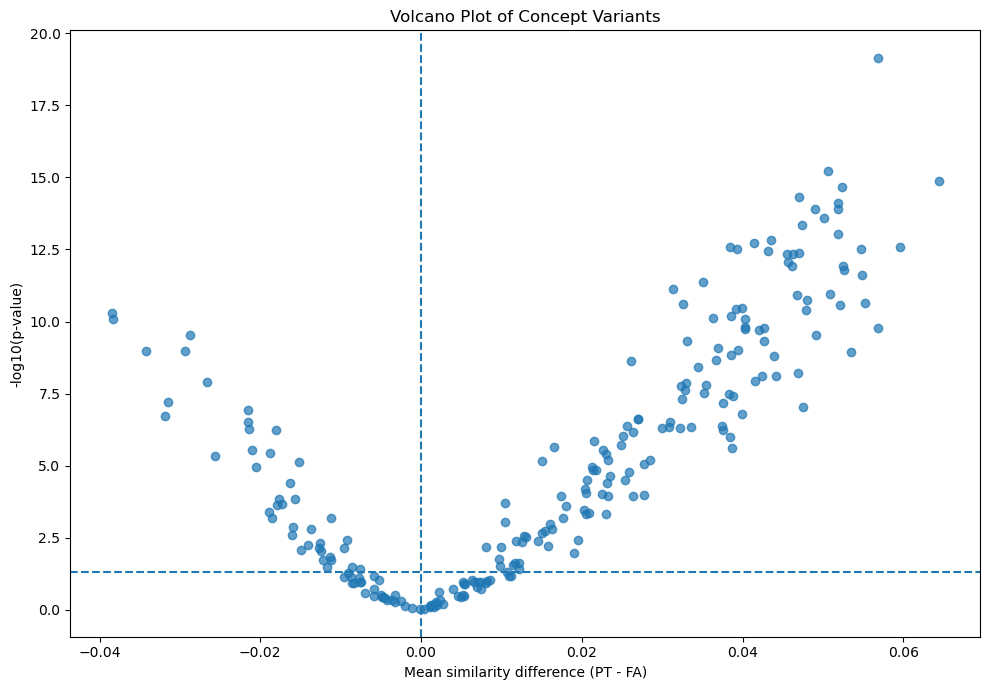

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(
    volcano_df["diff_PT_FA"],
    volcano_df["neglog10_p"],
    alpha=0.7
)

plt.axvline(0, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("Mean similarity difference (PT - FA)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot of Concept Variants")
plt.tight_layout()
plt.show()

<Figure size 1100x800 with 0 Axes>

Text(0.06439967540468267, 14.879299757002034, 'necrosis within hypercellular stroma')

Text(0.05960640239328674, 12.588938799488162, 'stromal overgrowth with absent epitheliu')

Text(0.056881352928702875, 9.762104397587422, 'frequent mitoses in hypercellular stroma')

Text(0.056799114124128344, 19.148548333226177, 'mitotic hotspot in hypercellular stroma')

...

Text(-0.02880316173382369, 9.532231081731746, 'breast histopathology image showing fat ')

Text(-0.02668429395031663, 7.890017610783445, 'breast histopathology image showing mild')

Text(0.5, 0, 'Mean similarity difference (PT - FA)')

Text(0, 0.5, '-log10(p-value)')

Text(0.5, 1.0, 'Volcano Plot of Concept Variants')

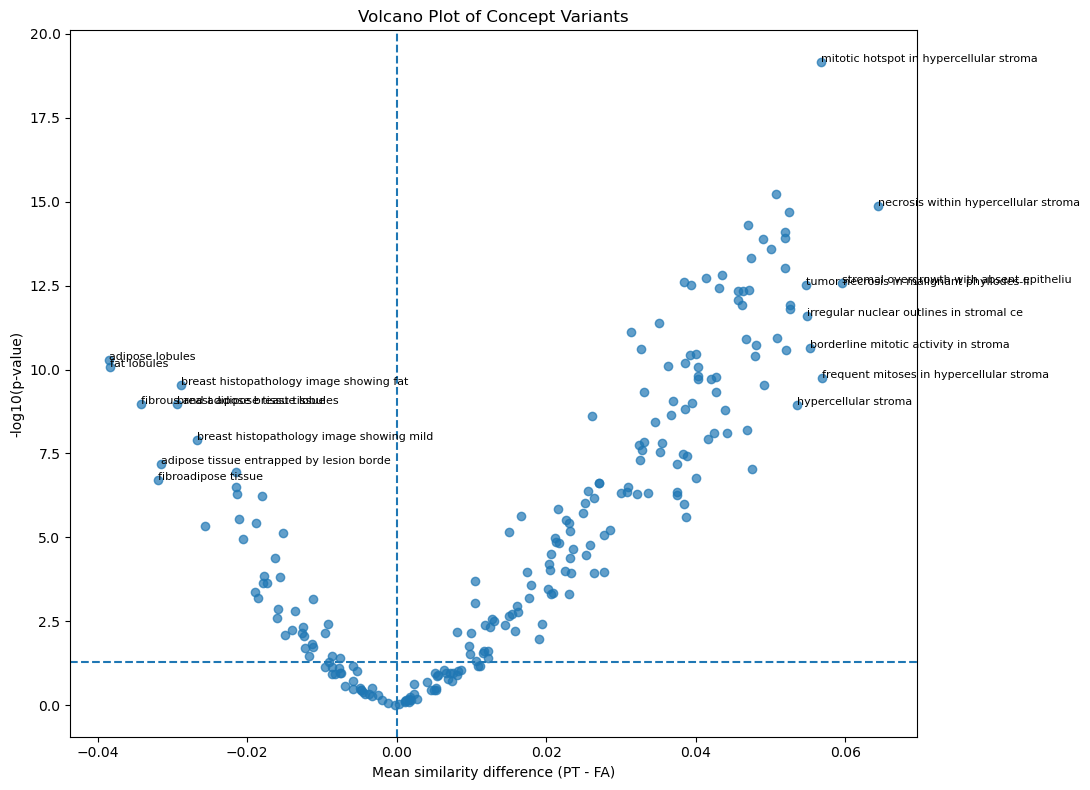

In [54]:
top_pt = volcano_df.sort_values(["diff_PT_FA", "neglog10_p"], ascending=[False, False]).head(8)
top_fa = volcano_df.sort_values(["diff_PT_FA", "neglog10_p"], ascending=[True, False]).head(8)
to_label = pd.concat([top_pt, top_fa], axis=0)

plt.figure(figsize=(11, 8))
plt.scatter(
    volcano_df["diff_PT_FA"],
    volcano_df["neglog10_p"],
    alpha=0.7
)

plt.axvline(0, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

for _, r in to_label.iterrows():
    plt.text(
        r["diff_PT_FA"],
        r["neglog10_p"],
        r["variant_text"][:40],
        fontsize=8
    )

plt.xlabel("Mean similarity difference (PT - FA)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot of Concept Variants")
plt.tight_layout()
plt.show()

In [35]:
# average variants per concept per slide
concept_slide_df = (
    df.groupby(["slide_id", "true_label_str", "concept_name"])
      ["mean_similarity"]
      .mean()
      .reset_index()
)

In [36]:
from scipy.stats import ttest_ind
import numpy as np

rows = []

for concept, g in concept_slide_df.groupby("concept_name"):
    fa = g.loc[g["true_label_str"] == "FA", "mean_similarity"].values
    pt = g.loc[g["true_label_str"] == "PT", "mean_similarity"].values

    if len(fa) < 2 or len(pt) < 2:
        continue

    stat, p = ttest_ind(pt, fa, equal_var=False, nan_policy="omit")
    diff = pt.mean() - fa.mean()

    rows.append({
        "concept_name": concept,
        "mean_FA": fa.mean(),
        "mean_PT": pt.mean(),
        "diff_PT_FA": diff,
        "p_value": p,
        "neglog10_p": -np.log10(max(p, 1e-300)),
    })

concept_volcano_df = pd.DataFrame(rows)
concept_volcano_df = concept_volcano_df.sort_values("diff_PT_FA", ascending=False)

concept_volcano_df.head()

,concept_name,mean_FA,mean_PT,diff_PT_FA,p_value,neglog10_p
42,stromal_mitosis,0.093483,0.132323,0.038840,8.629054e-14,13.064037
6,borderline_mitotic_activity,0.106203,0.144734,0.038532,8.135678e-11,10.089606
31,myxoid_stroma,0.067124,0.104584,0.037460,2.694490e-10,9.569523
43,stromal_overgrowth,0.117415,0.154778,0.037363,1.500544e-10,9.823751
15,high_mitotic_activity,0.105981,0.143157,0.037175,1.199216e-13,12.921102


<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 'Mean similarity difference (PT - FA)')

Text(0, 0.5, '-log10(p-value)')

Text(0.5, 1.0, 'Concept-Level Volcano Plot')

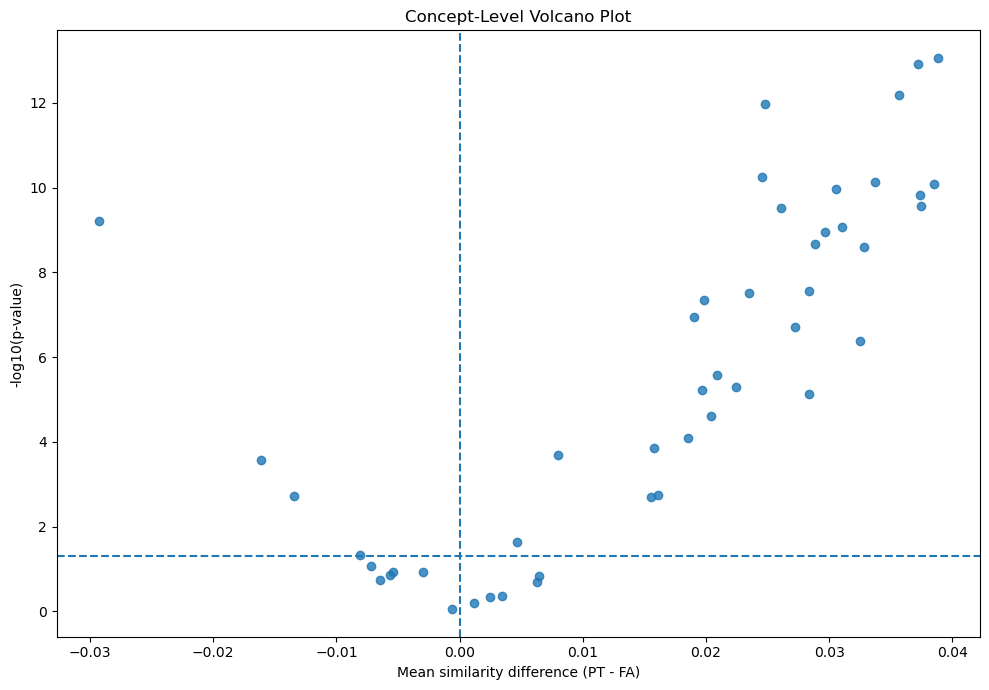

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    concept_volcano_df["diff_PT_FA"],
    concept_volcano_df["neglog10_p"],
    alpha=0.8
)

plt.axvline(0, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("Mean similarity difference (PT - FA)")
plt.ylabel("-log10(p-value)")
plt.title("Concept-Level Volcano Plot")

plt.tight_layout()
plt.show()

<Figure size 1100x800 with 0 Axes>

Text(0.03883997069785414, 13.06403678851999, 'stromal_mitosis')

Text(0.038531870234170124, 10.089606222601734, 'borderline_mitotic_activity')

Text(0.037459622468936374, 9.569523444927437, 'myxoid_stroma')

Text(0.03736272195164961, 9.823751262420549, 'stromal_overgrowth')

...

Text(-0.008046219479666467, 1.3348499092024693, 'periepithelial_stromal_condensation')

Text(-0.0071737066484920675, 1.0645336431961234, 'background_parenchyma')

Text(0.5, 0, 'Mean similarity difference (PT - FA)')

Text(0, 0.5, '-log10(p-value)')

Text(0.5, 1.0, 'Concept-Level Volcano Plot')

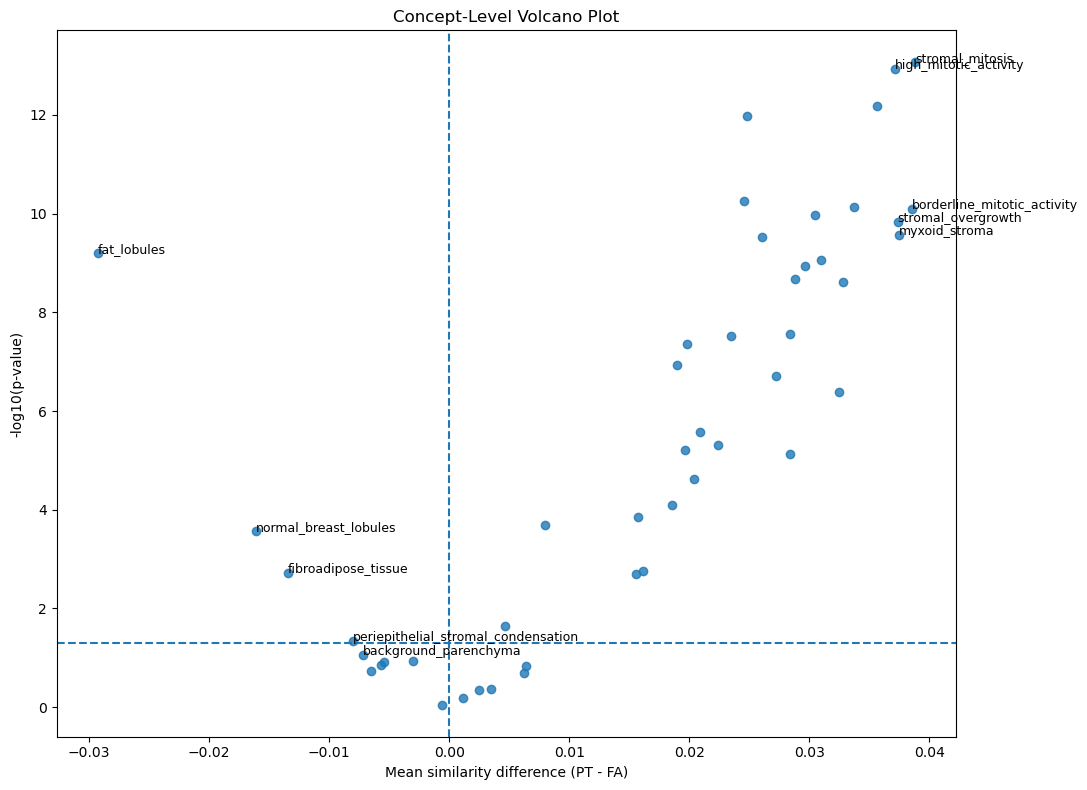

In [38]:
top_pt = concept_volcano_df.sort_values(
    ["diff_PT_FA", "neglog10_p"],
    ascending=[False, False]
).head(5)

top_fa = concept_volcano_df.sort_values(
    ["diff_PT_FA", "neglog10_p"],
    ascending=[True, False]
).head(5)

to_label = pd.concat([top_pt, top_fa])

plt.figure(figsize=(11, 8))

plt.scatter(
    concept_volcano_df["diff_PT_FA"],
    concept_volcano_df["neglog10_p"],
    alpha=0.8
)

plt.axvline(0, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

for _, r in to_label.iterrows():
    plt.text(
        r["diff_PT_FA"],
        r["neglog10_p"],
        r["concept_name"],
        fontsize=9
    )

plt.xlabel("Mean similarity difference (PT - FA)")
plt.ylabel("-log10(p-value)")
plt.title("Concept-Level Volcano Plot")

plt.tight_layout()
plt.show()

In [39]:
out_csv = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_volcano_stats.csv"
concept_volcano_df.to_csv(out_csv, index=False)

pruning concept bank variants

In [ ]:
# keep top 2
import pandas as pd
import json
from copy import deepcopy

# ---------- paths ----------
volcano_csv = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\variant_volcano_stats.csv"
bank_json   = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_map.json"
out_json    = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_map_top2.json"

# ---------- load ----------
vol = pd.read_csv(volcano_csv)

with open(bank_json, "r", encoding="utf-8") as f:
    bank = json.load(f)

# ---------- optional: expected direction per group ----------
# PT-like groups should have positive diff_PT_FA
# FA/NORMAL-like groups should have negative diff_PT_FA
pt_groups = {"PT_lean", "PT_benign_like", "PT_borderline_like", "PT_malignant_like", "mitosis"}
fa_groups = {"FA_lean", "NORMAL_lean"}

# map concept -> group from JSON
concept_to_group = {}
for grp, concept_dict in bank["concepts"].items():
    for concept_name in concept_dict.keys():
        concept_to_group[concept_name] = grp

vol["concept_group"] = vol["concept_name"].map(concept_to_group)

# ---------- filtering ----------
# keep only reasonably useful variants
vol = vol[vol["p_value"] < 0.05].copy()
vol = vol[vol["diff_PT_FA"].abs() >= 0.01].copy()

# enforce expected direction
keep_mask = []
for _, r in vol.iterrows():
    grp = r["concept_group"]
    d = r["diff_PT_FA"]
    ok = True
    if grp in pt_groups:
        ok = d > 0
    elif grp in fa_groups:
        ok = d < 0
    keep_mask.append(ok)

vol = vol[pd.Series(keep_mask, index=vol.index)].copy()

# rank within each concept by abs effect size, then p-value
vol = vol.sort_values(
    by=["concept_name", "diff_PT_FA", "p_value"],
    ascending=[True, False, True]
)

top2 = (
    vol.assign(abs_diff=vol["diff_PT_FA"].abs())
       .sort_values(["concept_name", "abs_diff", "p_value"], ascending=[True, False, True])
       .groupby("concept_name", as_index=False)
       .head(2)
       .copy()
)

# ---------- rebuild JSON ----------
new_bank = deepcopy(bank)

for grp, concept_dict in new_bank["concepts"].items():
    for concept_name in list(concept_dict.keys()):
        keep_variants = top2.loc[top2["concept_name"] == concept_name, "variant_text"].tolist()

        # fallback: if nothing passed filters, keep original first variant
        if len(keep_variants) == 0:
            keep_variants = concept_dict[concept_name][:1]

        concept_dict[concept_name] = keep_variants

# ---------- save ----------
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(new_bank, f, indent=2, ensure_ascii=False)

print("Saved:", out_json)

# optional summary
summary = (
    top2.groupby("concept_name")
        .agg(
            n_kept=("variant_text", "count"),
            best_abs_diff=("diff_PT_FA", lambda x: x.abs().max()),
            best_p=("p_value", "min")
        )
        .reset_index()
)
print(summary.head(20))

In [50]:
# top 3 ish 
import pandas as pd
import json
from copy import deepcopy

volcano_csv = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\variant_volcano_stats.csv"
bank_json   = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_concept_map.json"
out_json    = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_top3_concept_map_balanced.json"

vol = pd.read_csv(volcano_csv)

with open(bank_json, "r", encoding="utf-8") as f:
    bank = json.load(f)

# map concept -> group
concept_to_group = {}
for grp, concept_dict in bank["concepts"].items():
    for concept_name in concept_dict.keys():
        concept_to_group[concept_name] = grp

vol["concept_group"] = vol["concept_name"].map(concept_to_group)

pt_groups = {"PT_lean", "PT_benign_like", "PT_borderline_like", "PT_malignant_like", "mitosis"}
fa_groups = {"FA_lean", "NORMAL_lean"}

# expected direction
def direction_ok(row):
    grp = row["concept_group"]
    d = row["diff_PT_FA"]
    if grp in pt_groups:
        return d > 0
    if grp in fa_groups:
        return d < 0
    return True

vol = vol[vol.apply(direction_ok, axis=1)].copy()
vol["abs_diff"] = vol["diff_PT_FA"].abs()

# soft filter
vol_keep = vol[(vol["p_value"] < 0.05) & (vol["abs_diff"] >= 0.02)].copy()

# top 3 among filtered
top3 = (
    vol_keep.sort_values(["concept_name", "abs_diff", "p_value"], ascending=[True, False, True])
            .groupby("concept_name", as_index=False)
            .head(3)
            .copy()
)

# fallback: if a concept has <2 kept, use best-ranked original variants to bring it up to 2
fallback_ranked = (
    vol.sort_values(["concept_name", "abs_diff", "p_value"], ascending=[True, False, True])
       .copy()
)

selected = []

for concept_name in concept_to_group.keys():
    cur = top3[top3["concept_name"] == concept_name].copy()

    if len(cur) < 2:
        extra = fallback_ranked[fallback_ranked["concept_name"] == concept_name].copy()
        already = set(cur["variant_text"].tolist())
        extra = extra[~extra["variant_text"].isin(already)].head(2 - len(cur))
        cur = pd.concat([cur, extra], axis=0)

    selected.append(cur)

selected_df = pd.concat(selected, axis=0).drop_duplicates(
    subset=["concept_name", "variant_text"]
)

# optionally remove whole weak concepts
concept_summary = (
    selected_df.groupby("concept_name")
    .agg(
        n_kept=("variant_text", "count"),
        best_abs_diff=("abs_diff", "max"),
        best_p=("p_value", "min")
    )
    .reset_index()
)

weak_concepts = set(
    concept_summary[
        (concept_summary["best_abs_diff"] < 0.015) &
        (concept_summary["best_p"] > 0.05)
    ]["concept_name"].tolist()
)

new_bank = deepcopy(bank)

for grp, concept_dict in new_bank["concepts"].items():
    for concept_name in list(concept_dict.keys()):
        if concept_name in weak_concepts:
            del concept_dict[concept_name]
            continue

        keep_variants = selected_df.loc[
            selected_df["concept_name"] == concept_name, "variant_text"
        ].tolist()

        if len(keep_variants) == 0:
            keep_variants = concept_dict[concept_name][:2]

        concept_dict[concept_name] = keep_variants[:3]

with open(out_json, "w", encoding="utf-8") as f:
    json.dump(new_bank, f, indent=2, ensure_ascii=False)

print("Saved:", out_json)

summary_out = out_json.replace(".json", "_summary.csv")
concept_summary.to_csv(summary_out, index=False)
print("Saved:", summary_out)

Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_top3_concept_map_balanced.json
Saved: C:\Users\Vivian\Documents\CONCH\test_text_encoder\V3_concept_prior\V3_top3_concept_map_balanced_summary.csv
